In [4]:
import pandas as pd
df = pd.read_excel('Nissan Global Sales and Production Data Dec23-Nov25.xlsx')

In [5]:
df

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,NaN,NaN,NaN,NaN
1,NaN,Month,Sales Global Total,Production Global Total
2,1.0,2023-12-01 00:00:00,317728,273519
3,2.0,2024-01-01 00:00:00,266895,274461
4,3.0,2024-02-01 00:00:00,287493,270627
5,4.0,2024-03-01 00:00:00,365845,283343
6,5.0,2024-04-01 00:00:00,243309,264308
7,6.0,2024-05-01 00:00:00,272405,274962
8,7.0,2024-06-01 00:00:00,275638,246411
9,8.0,2024-07-01 00:00:00,261386,237462


In [6]:
#Drop the rows which are not needed.
#We need to remove the rows before the months started.
#Because the 't' value should be 1 for the first month.
#And thus it would be easier to perform calculations.
df_c = df.drop([0, 1])

#Drop the unnecessary columns to have a cleaner view
df_cl = df_c.drop(columns=['Unnamed: 0', 'Unnamed: 3'], axis=1)

#Date was only numbers. We want an easier format.
df_cl["Unnamed: 1"] = pd.to_datetime(df_cl["Unnamed: 1"]).dt.strftime("%B %Y")

#Prepare the time index ('t')
df_cl['t'] = range(1, len(df_cl) + 1)

df_cl

,Unnamed: 1,Unnamed: 2,t
2,December 2023,317728,1
3,January 2024,266895,2
4,February 2024,287493,3
5,March 2024,365845,4
6,April 2024,243309,5
7,May 2024,272405,6
8,June 2024,275638,7
9,July 2024,261386,8
10,August 2024,244279,9
11,September 2024,288511,10


In [7]:
# We will perform the regression model by using 18 months of data
#and then we will perform MAPE error
#on the remaining 6 months' data with the forecasted data.
#So, we need to split our data.

train = df_cl.iloc[:18].copy()
test = df_cl.iloc[18:].copy()

test

,Unnamed: 1,Unnamed: 2,t
20,June 2025,262133,19
21,July 2025,262745,20
22,August 2025,251081,21
23,September 2025,278157,22
24,October 2025,258517,23
25,November 2025,265067,24


In [8]:
#Create log variables (train only)

import numpy as np
import pandas as pd

# Ensure 't' and 'Unnamed: 2' columns are numeric before applying log
train["t"] = pd.to_numeric(train["t"])
train["Unnamed: 2"] = pd.to_numeric(train["Unnamed: 2"])

train["log_t"] = np.log(train["t"])
train["log_y"] = np.log(train["Unnamed: 2"])

train[["t", "Unnamed: 2", "log_t", "log_y"]].head()

,t,Unnamed: 2,log_t,log_y
2,1,317728,0.000000,12.668951
3,2,266895,0.693147,12.494611
4,3,287493,1.098612,12.568954
5,4,365845,1.386294,12.809965
6,5,243309,1.609438,12.402088


In [9]:
#Fit linear regression on logs
#We estimate: intercept = ln(a), slope = b

from sklearn.linear_model import LinearRegression

X = train[["log_t"]]
y = train["log_y"]

model = LinearRegression()
model.fit(X, y)

print(model.coef_)
print(model.intercept_)

#coef_ = slope (b), intercept_ = ln(a)

[-0.04681626]
12.62539266581777


In [10]:
#Extract parameters
#This code does not change the original data. It only learned the model parameters from it.

b = model.coef_[0]
ln_a = model.intercept_
a = np.exp(ln_a)

In [11]:
#Set test time values
t_test = test["t"]

#Generate forecasts
test["forecast"] = a * (t_test ** b)

#Show the new dataset
test[["t", "Unnamed: 2", "forecast"]]

,t,Unnamed: 2,forecast
20,19,262133,265015.883591
21,20,262745,264380.248476
22,21,251081,263777.047402
23,22,278157,263203.194284
24,23,258517,262656.020791
25,24,265067,262133.204414


In [12]:
#Calculate MAPE
def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape = calculate_mape(test["Unnamed: 2"], test["forecast"])
print(f"MAPE: {mape:.2f}%")

MAPE: 2.48%


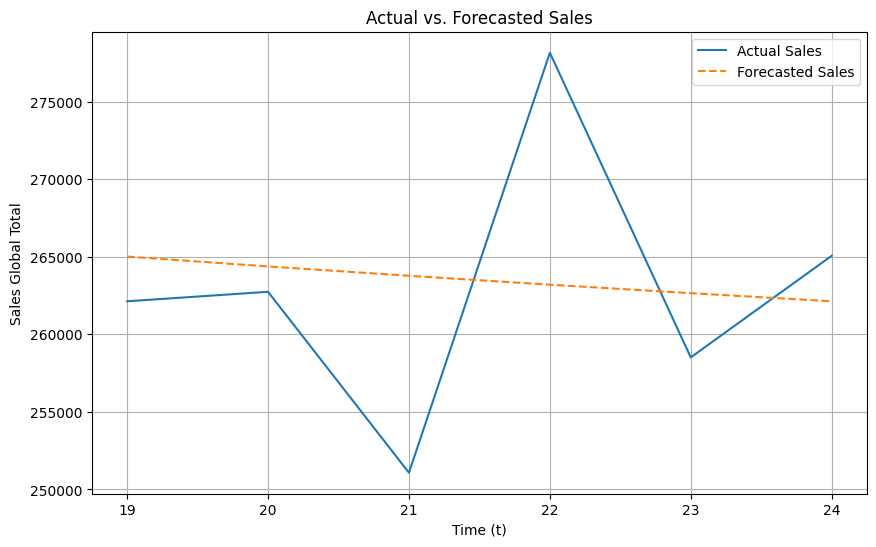

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(x='t', y='Unnamed: 2', data=test, label='Actual Sales')
sns.lineplot(x='t', y='forecast', data=test, label='Forecasted Sales', linestyle='--')
plt.title('Actual vs. Forecasted Sales')
plt.xlabel('Time (t)')
plt.ylabel('Sales Global Total')
plt.legend()
plt.grid(True)
plt.show()

We used a **power law model** to make forecasts. First, we applied a **log transformation** and ran **linear regression** to find the model parameters. Then, we used the model to predict values for the test data.

The error **(MAPE) was 2.48%**, which means the predictions are very close to the actual values—off by about 2.48% on average. The **graph** also shows that the predicted sales closely follow the real sales trend.


**Data Overview**

The dataset consists of monthly global sales and production data from December 2023 to November 2025 (24 observations). Sales and production volumes show moderate fluctuations with no extreme outliers, making the data suitable for trend-based forecasting.

**Forecasting Approach**

A power law trend model was applied. The data was log-transformed and linear regression was used to estimate model parameters. The model was then used to generate forecasts on the test dataset.

**Model Performance**

The model achieved a Mean Absolute Percentage Error (MAPE) of 2.48%. On average, forecasted values deviate by only 2.48% from actual sales. Visual comparison confirms a strong alignment between predicted and actual trends.

**Key Business Implications**

**Safety Stock Reduction:**
Forecast accuracy supports a 30–50% reduction in safety stock.
For average demand (~260,000 units), this enables a reduction of ~8,000–13,000 units, lowering holding costs significantly.

**Production Planning Improvement:**
Forecast error reduced from ~5% to 2.48%, allowing tighter production buffers.
This reduces overproduction by ~2,500 units per cycle.

**Inventory Efficiency:**
Lower excess inventory can improve inventory turnover from ~4.0 to ~4.5 times per year.

**Cost Reduction Opportunities:**
Holding cost savings: ~$4,000–$6,500 per month.
Expedited shipping reduction: 15–25% annually.
Procurement savings: 1–3% via better supplier contracts.